In [841]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [842]:
training_data = pd.read_csv('./dataset/train.csv')
test_data = pd.read_csv('./dataset/test.csv')

In [843]:
print(training_data.shape)
print(test_data.shape)

(891, 12)
(418, 11)


In [844]:
training_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [845]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# check the data balance

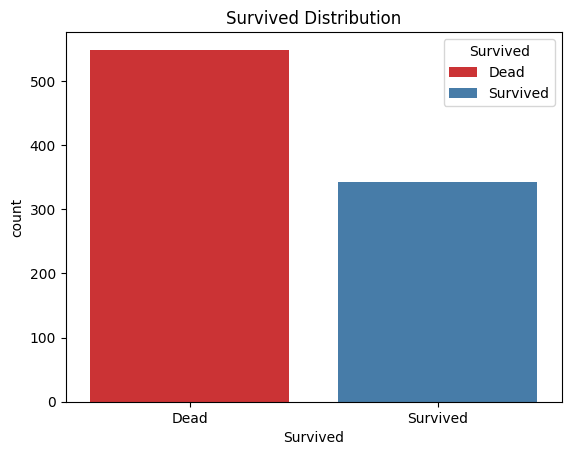

In [846]:
# The first chart shows that more passengers died than survived.
sns.countplot(x='Survived', data=training_data, hue='Survived', palette='Set1')
plt.title('Survived Distribution')
plt.xticks([0,1], ['Dead', 'Survived'])
plt.legend(title='Survived', labels=['Dead', 'Survived'])
plt.show()

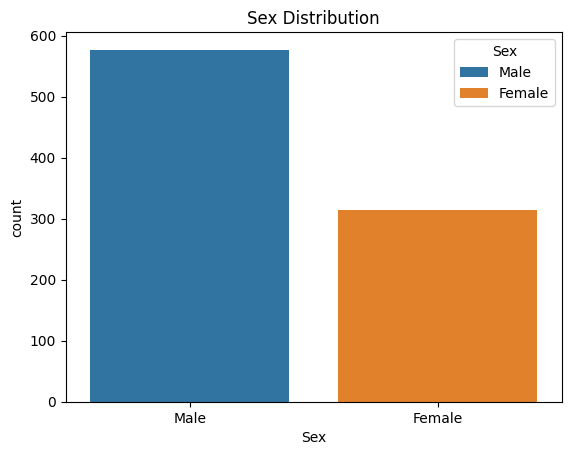

In [847]:
# The second chart shows that there were more male passengers than female passengers. 
sns.countplot(x='Sex', data=training_data, hue='Sex')
plt.title('Sex Distribution')
plt.xticks([0,1], ['Male', 'Female'])
plt.legend(title='Sex', labels=['Male', 'Female'])
plt.show()


# feature analysis

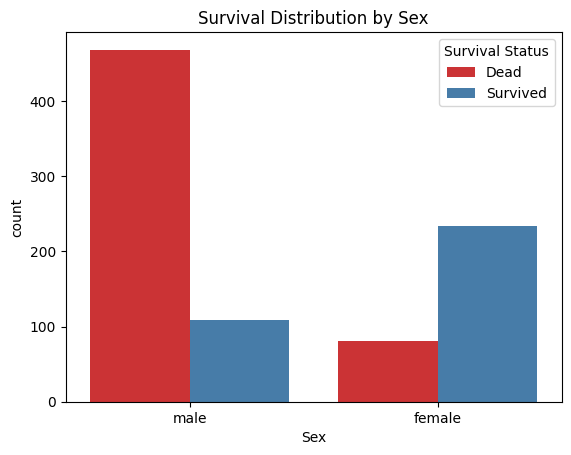

In [848]:
#The third chart shows that most men died, but many women survived.So,Sex is an important feature.
sns.countplot(x='Sex', data=training_data, hue='Survived', palette='Set1')
plt.title('Survival Distribution by Sex')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

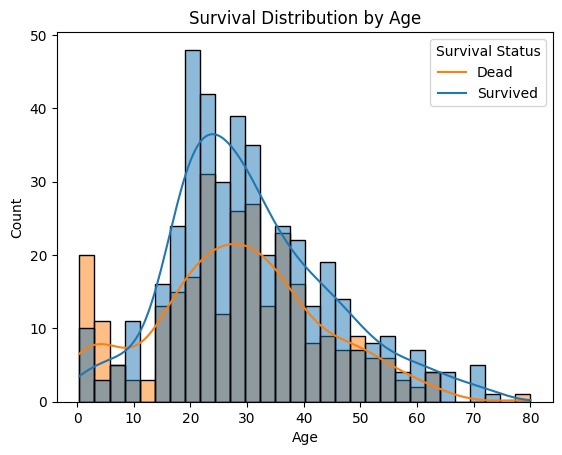

In [849]:
# The Age chart shows that most passengers were between 20 and 40 years old.
sns.histplot(x='Age', data=training_data, hue='Survived', bins=30, kde=True)
plt.title('Survival Distribution by Age')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

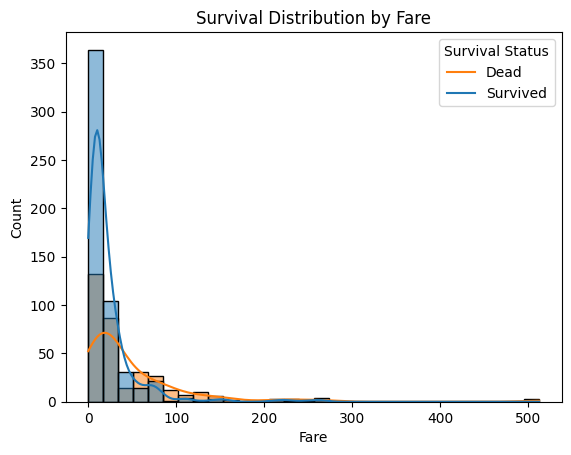

In [850]:
# The Fare chart shows that most passengers paid low fares, but passengers with higher fares had a better survival chance.
sns.histplot(x='Fare', data=training_data, hue='Survived', bins=30, kde=True)
plt.title('Survival Distribution by Fare')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

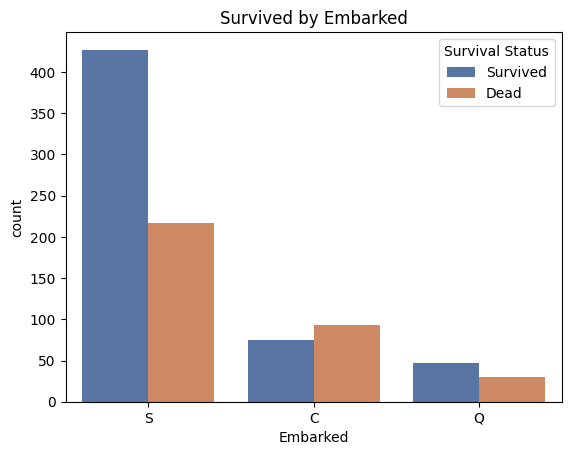

In [851]:
# Most passengers boarded from Southampton.Cherbourg passengers had the best survival rate.Queenstown had fewer passengers than Southampton.
sns.countplot(x='Embarked', data=training_data, hue='Survived', palette='deep')
plt.title('Survived by Embarked')
plt.legend(title='Survival Status', labels=['Survived', 'Dead'])
plt.show()

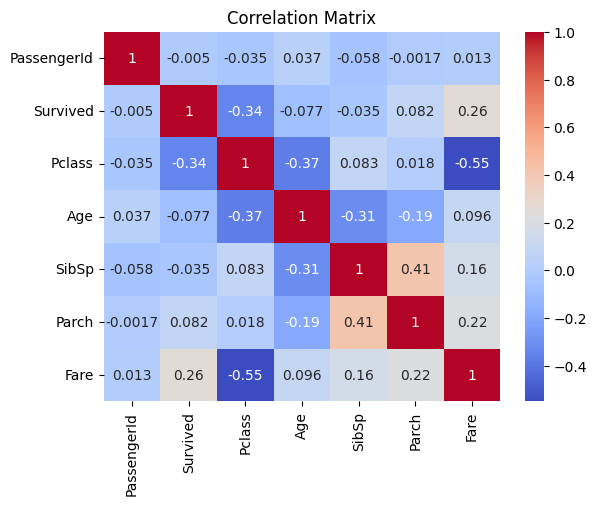

In [852]:
# correlation Matrix
correlation_matrix = training_data.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# data cleaning

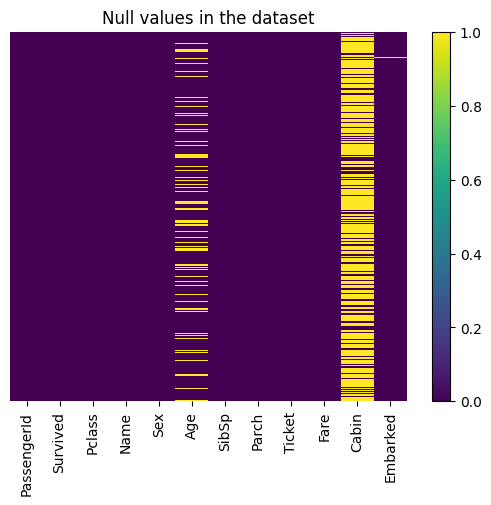

In [853]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

In [854]:
# we drop the Cabin column because it has too many missing values
training_data = training_data.drop('Cabin', axis=1)
test_data = test_data.drop('Cabin', axis=1)

In [855]:
# for age column, we fill the missing values with the median of the age column
training_data['Age'] = training_data['Age'].fillna(training_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())

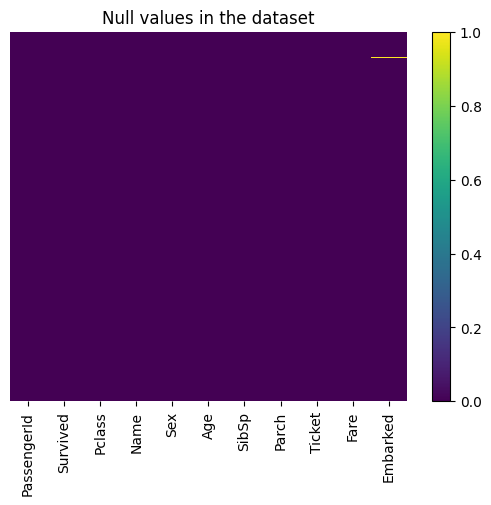

In [856]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

In [857]:
# fill missing values in the embarked column with the mode of the embarked column
training_data['Embarked'] = training_data['Embarked'].fillna(training_data['Embarked'].mode()[0])
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

In [858]:
training_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

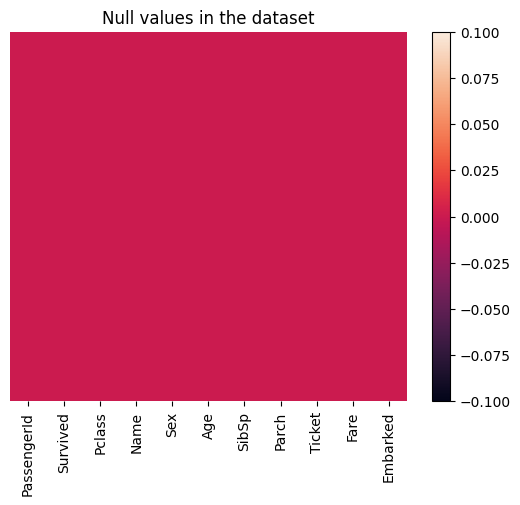

In [859]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False)
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

## categorical to numerical transformation

In [860]:
# drop the Name, Ticket and PassengerId
training_data.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)
test_data.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)

In [861]:
# encode categorical features
training_data['Sex'] = training_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

In [862]:
# one-hot encoding to Embarked column
training_data = pd.get_dummies(training_data, columns=['Embarked'], drop_first=False, dtype=int)
test_data = pd.get_dummies(test_data, columns=['Embarked'], drop_first=False, dtype=int)
training_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [863]:
# training_data['Embarked_C'] = training_data['Embarked_C'].map({True: 1, False: 0})
# training_data['Embarked_Q'] = training_data['Embarked_Q'].map({True: 1, False: 0})
# training_data['Embarked_S'] = training_data['Embarked_S'].map({True: 1, False: 0})
# training_data.head()

In [864]:
# combining SibSp and Parch
training_data['FamilySize'] = training_data['SibSp'] + training_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
training_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,0,1,2
1,1,1,1,38.0,1,0,71.2833,1,0,0,2
2,1,3,1,26.0,0,0,7.9250,0,0,1,1
3,1,1,1,35.0,1,0,53.1000,0,0,1,2
4,0,3,0,35.0,0,0,8.0500,0,0,1,1


In [865]:
# del SibSp and Parch column
training_data = training_data.drop(['SibSp', 'Parch'], axis=1)
test_data = test_data.drop(['SibSp', 'Parch'], axis=1)
training_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,7.2500,0,0,1,2
1,1,1,1,38.0,71.2833,1,0,0,2
2,1,3,1,26.0,7.9250,0,0,1,1
3,1,1,1,35.0,53.1000,0,0,1,2
4,0,3,0,35.0,8.0500,0,0,1,1


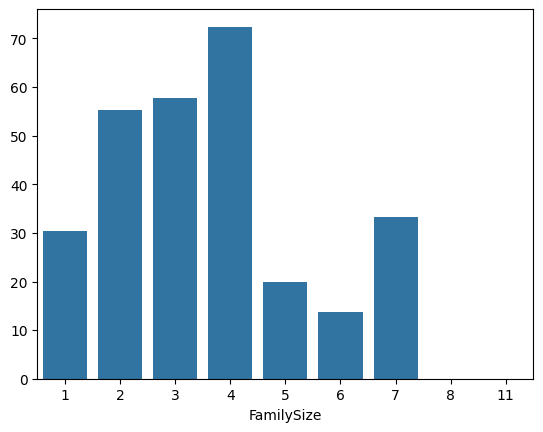

In [866]:
# data ro bar asase family goroup bandi mikone bad mean survivedo dar har gorouh migire * 100 mikone.
perce_survival = training_data.groupby("FamilySize")["Survived"].mean()*100 
sns.barplot(x=perce_survival.index, y=perce_survival.values)
plt.show()

## Train/ Validation split

In [867]:
from sklearn.model_selection import train_test_split

In [868]:
training_features = training_data.drop(['Survived'], axis=1)
training_labels = training_data['Survived']

In [869]:
training_labels.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [870]:
training_features.head()

,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,3,0,22.0,7.2500,0,0,1,2
1,1,1,38.0,71.2833,1,0,0,2
2,3,1,26.0,7.9250,0,0,1,1
3,1,1,35.0,53.1000,0,0,1,2
4,3,0,35.0,8.0500,0,0,1,1


In [871]:
test_data.head()

,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,3,0,34.5,7.8292,0,1,0,1
1,3,1,47.0,7.0000,0,0,1,2
2,2,0,62.0,9.6875,0,1,0,1
3,3,0,27.0,8.6625,0,0,1,1
4,3,1,22.0,12.2875,0,0,1,3


In [872]:
X_train, X_test, y_train, y_test = train_test_split(training_features, training_labels, test_size=0.2)

In [873]:
print(f'X_train shape: {X_train.shape} - X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape} - y_test shape: {y_test.shape}')

X_train shape: (712, 8) - X_test shape: (179, 8)
y_train shape: (712,) - y_test shape: (179,)


# pre-processing

In [874]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [875]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [876]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluation_metrics(y_train, y_pred_train, y_test, y_pred_test):
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    print(f'Accuracy Train: {accuracy_train}')
    print(f'Accuracy Test: {accuracy_test}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1_Score:{f1}')

    print('\nConfusion_Matrix:')
    print(confusion_matrix(y_test, y_pred_test))
    
    print('\nClassification_Report:')
    print(classification_report(y_test, y_pred_test))
    
    return accuracy_train, accuracy_test, precision, recall, f1

## Model training

### 1.KNN

In [877]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train, y_train)
y_pred_train_knn = knn.predict(X_train)
y_pred_test_knn = knn.predict(X_test)

accuracy_train_knn, accuracy_test_knn, precision_knn, recall_knn, f1_knn = evaluation_metrics(y_train, y_pred_train_knn, y_test, y_pred_test_knn)

Accuracy Train: 0.824438202247191
Accuracy Test: 0.8491620111731844
Precision: 0.828125
Recall: 0.7681159420289855
F1_Score:0.7969924812030075

Confusion_Matrix:
[[99 11]
 [16 53]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       110
           1       0.83      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



### 2. GaussianNB

In [878]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_train_nb = nb.predict(X_train)
y_pred_test_nb = nb.predict(X_test)

accuracy_train_nb, accuracy_test_nb, precision_nb, recall_nb, f1_nb = evaluation_metrics(y_train, y_pred_train_nb, y_test, y_pred_test_nb)

Accuracy Train: 0.7893258426966292
Accuracy Test: 0.8268156424581006
Precision: 0.7638888888888888
Recall: 0.7971014492753623
F1_Score:0.7801418439716312

Confusion_Matrix:
[[93 17]
 [14 55]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       110
           1       0.76      0.80      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



### 3. Decision Tree

In [879]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=4, min_samples_split=10)
dt.fit(X_train, y_train)
y_pred_train_dt = dt.predict(X_train)
y_pred_test_dt = dt.predict(X_test)

accuracy_train_dt, accuracy_test_dt, precision_dt, recall_dt, f1_dt = evaluation_metrics(y_train, y_pred_train_dt, y_test, y_pred_test_dt)

Accuracy Train: 0.8455056179775281
Accuracy Test: 0.8379888268156425
Precision: 0.7777777777777778
Recall: 0.8115942028985508
F1_Score:0.7943262411347518

Confusion_Matrix:
[[94 16]
 [13 56]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       110
           1       0.78      0.81      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



### 4. Random Forest

In [880]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features='sqrt')
rf.fit(X_train, y_train)
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

accuracy_train_rf, accuracy_test_rf, precision_rf, recall_rf, f1_rf = evaluation_metrics(y_train, y_pred_train_rf, y_test, y_pred_test_rf)

Accuracy Train: 0.8497191011235955
Accuracy Test: 0.8491620111731844
Precision: 0.8387096774193549
Recall: 0.7536231884057971
F1_Score:0.7938931297709924

Confusion_Matrix:
[[100  10]
 [ 17  52]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       110
           1       0.84      0.75      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



### 5. Logistic Regression

In [881]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr = lr.predict(X_test)

accuracy_train_lr, accuracy_test_lr, precision_lr, recall_lr, f1_lr = evaluation_metrics(y_train, y_pred_train_lr, y_test, y_pred_test_lr)

Accuracy Train: 0.7963483146067416
Accuracy Test: 0.8156424581005587
Precision: 0.7432432432432432
Recall: 0.7971014492753623
F1_Score:0.7692307692307693

Confusion_Matrix:
[[91 19]
 [14 55]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       110
           1       0.74      0.80      0.77        69

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### 6. SVM

In [882]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)
y_pred_train_svm = svm.predict(X_train)
y_pred_test_svm = svm.predict(X_test)

accuracy_train_svm, accuracy_test_svm, precision_svm, recall_svm, f1_svm = evaluation_metrics(y_train, y_pred_train_svm, y_test, y_pred_test_svm)

Accuracy Train: 0.8258426966292135
Accuracy Test: 0.8435754189944135
Precision: 0.8253968253968254
Recall: 0.7536231884057971
F1_Score:0.7878787878787878

Confusion_Matrix:
[[99 11]
 [17 52]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       110
           1       0.83      0.75      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



### 7. ANN

In [883]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=50, max_iter=600, activation='relu', solver='adam')
mlp.fit(X_train, y_train)
y_pred_train_mlp = mlp.predict(X_train)
y_pred_test_mlp = mlp.predict(X_test)

accuracy_train_mlp, accuracy_test_mlp, precision_mlp, recall_mlp, f1_mlp = evaluation_metrics(y_train, y_pred_train_mlp, y_test, y_pred_test_mlp)

Accuracy Train: 0.8469101123595506
Accuracy Test: 0.8324022346368715
Precision: 0.7910447761194029
Recall: 0.7681159420289855
F1_Score:0.7794117647058824

Confusion_Matrix:
[[96 14]
 [16 53]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       110
           1       0.79      0.77      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



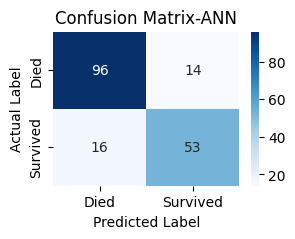

In [884]:
# confusion_matrix - ANN
cm = confusion_matrix(y_test, y_pred_test_mlp)
plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt ='d', cmap='Blues', xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix-ANN')
plt.show()

## Model Performance Comparison Tables

In [885]:
results = pd.DataFrame({
    'Model': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'ANN'],
    'Accuracy Train': [accuracy_train_knn,accuracy_train_nb,accuracy_train_dt,accuracy_train_rf,accuracy_train_lr,accuracy_train_svm,accuracy_train_mlp],
    'Accuracy Validation': [accuracy_test_knn,accuracy_test_nb,accuracy_test_dt,accuracy_test_rf,accuracy_test_lr,accuracy_test_svm,accuracy_test_mlp],
    'Precision': [precision_knn,precision_nb,precision_dt,precision_rf,precision_lr,precision_svm,precision_mlp],
    'Recall': [recall_knn,recall_nb,recall_dt,recall_rf,recall_lr,recall_svm,recall_mlp],
    'F1 Score': [f1_knn, f1_nb, f1_dt, f1_rf, f1_lr, f1_svm, f1_mlp]
})
results

,Model,Accuracy Train,Accuracy Validation,Precision,Recall,F1 Score
0,KNN,0.824438,0.849162,0.828125,0.768116,0.796992
1,GaussianNB,0.789326,0.826816,0.763889,0.797101,0.780142
2,Decision Tree,0.845506,0.837989,0.777778,0.811594,0.794326
3,Random Forest,0.849719,0.849162,0.838710,0.753623,0.793893
4,Logistic Regression,0.796348,0.815642,0.743243,0.797101,0.769231
5,SVM,0.825843,0.843575,0.825397,0.753623,0.787879
6,ANN,0.846910,0.832402,0.791045,0.768116,0.779412


## Model Performance Comparison

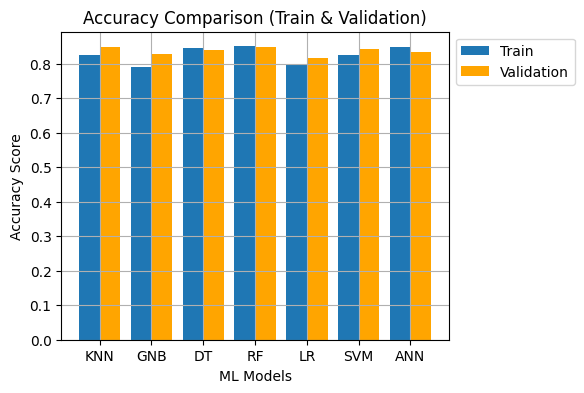

In [886]:
models = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
accuracy_train = [accuracy_train_knn,accuracy_train_nb,accuracy_train_dt,accuracy_train_rf,accuracy_train_lr,accuracy_train_svm,accuracy_train_mlp]
accuracy_test = [accuracy_test_knn,accuracy_test_nb,accuracy_test_dt,accuracy_test_rf,accuracy_test_lr,accuracy_test_svm,accuracy_test_mlp]

plt.figure(figsize=(5,4))
x = np.arange(len(models))
plt.bar(x, accuracy_train, width=0.4, label="Train")
plt.bar(x + 0.4, accuracy_test, width=0.4, label="Validation", color="orange")
plt.xticks(x + 0.2, models)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title('Accuracy Comparison (Train & Validation)')
plt.xlabel("ML Models")
plt.ylabel('Accuracy Score')
plt.grid()
plt.show()

## F1 Score Comparison

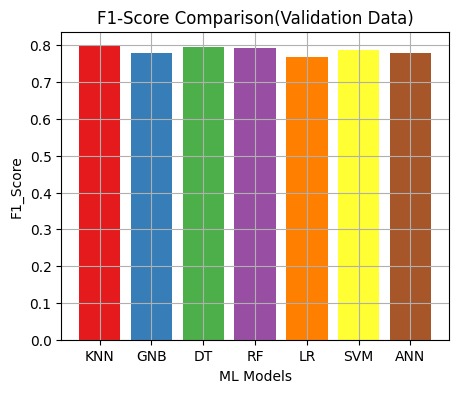

In [887]:
f1 = [f1_knn, f1_nb, f1_dt, f1_rf, f1_lr, f1_svm, f1_mlp]
models = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']

plt.figure(figsize=(5,4))
colors = plt.cm.Set1(range(len(models)))
plt.bar(models, f1, color=colors)
plt.title('F1-Score Comparison(Validation Data)')
plt.xlabel("ML Models")
plt.ylabel('F1_Score')
plt.grid()
plt.show()

# PCA

In [888]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

### 1.knn-PCA

In [889]:
knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train_pca, y_train)

y_pred_train_knn_pca = knn.predict(X_train_pca)
y_pred_test_knn_pca = knn.predict(X_test_pca)

accuracy_train_knn_pca, accuracy_test_knn_pca, precision_knn_pca, recall_knn_pca, f1_knn_pca = evaluation_metrics(y_train, y_pred_train_knn_pca, y_test, y_pred_test_knn_pca)

Accuracy Train: 0.8117977528089888
Accuracy Test: 0.8435754189944135
Precision: 0.8153846153846154
Recall: 0.7681159420289855
F1_Score:0.7910447761194029

Confusion_Matrix:
[[98 12]
 [16 53]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       110
           1       0.82      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



### 2. GaussianNB-PCA

In [890]:
nb = GaussianNB()
nb.fit(X_train_pca, y_train)

y_pred_train_nb_pca = nb.predict(X_train_pca)
y_pred_test_nb_pca = nb.predict(X_test_pca)

accuracy_train_nb_pca, accuracy_test_nb_pca, precision_nb_pca, recall_nb_pca, f1_nb_pca = evaluation_metrics(y_train, y_pred_train_nb_pca, y_test, y_pred_test_nb_pca)

Accuracy Train: 0.7794943820224719
Accuracy Test: 0.8156424581005587
Precision: 0.7571428571428571
Recall: 0.7681159420289855
F1_Score:0.762589928057554

Confusion_Matrix:
[[93 17]
 [16 53]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.77      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### 3. Decision Tree-PCA

In [891]:
dt = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=4, min_samples_split=10)
dt.fit(X_train_pca, y_train)
y_pred_train_dt_pca = dt.predict(X_train_pca)
y_pred_test_dt_pca = dt.predict(X_test_pca)

accuracy_train_dt_pca, accuracy_test_dt_pca, precision_dt_pca, recall_dt_pca, f1_dt_pca = evaluation_metrics(y_train, y_pred_train_dt_pca, y_test, y_pred_test_dt_pca)

Accuracy Train: 0.8567415730337079
Accuracy Test: 0.8212290502793296
Precision: 0.8135593220338984
Recall: 0.6956521739130435
F1_Score:0.75

Confusion_Matrix:
[[99 11]
 [21 48]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



### 4. Random Forest-PCA

In [892]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features='sqrt')
rf.fit(X_train_pca, y_train)
y_pred_train_rf_pca = rf.predict(X_train_pca)
y_pred_test_rf_pca = rf.predict(X_test_pca)

accuracy_train_rf_pca, accuracy_test_rf_pca, precision_rf_pca, recall_rf_pca, f1_rf_pca = evaluation_metrics(y_train, y_pred_train_rf_pca, y_test, y_pred_test_rf_pca)

Accuracy Train: 0.8778089887640449
Accuracy Test: 0.8268156424581006
Precision: 0.796875
Recall: 0.7391304347826086
F1_Score:0.7669172932330827

Confusion_Matrix:
[[97 13]
 [18 51]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



### 5.Logestic Regression-PCA

In [893]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_pca, y_train)

y_pred_train_lr_pca = lr.predict(X_train_pca)
y_pred_test_lr_pca = lr.predict(X_test_pca)

accuracy_train_lr_pca, accuracy_test_lr_pca, precision_lr_pca, recall_lr_pca, f1_lr_pca = evaluation_metrics(y_train, y_pred_train_lr_pca, y_test, y_pred_test_lr_pca)

Accuracy Train: 0.7724719101123596
Accuracy Test: 0.8044692737430168
Precision: 0.7361111111111112
Recall: 0.7681159420289855
F1_Score:0.75177304964539

Confusion_Matrix:
[[91 19]
 [16 53]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       110
           1       0.74      0.77      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.80       179
weighted avg       0.81      0.80      0.81       179



### 6. SVM-PCA

In [894]:
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_pca, y_train)
y_pred_train_svm_pca = svm.predict(X_train_pca)
y_pred_test_svm_pca = svm.predict(X_test_pca)

accuracy_train_svm_pca, accuracy_test_svm_pca, precision_svm_pca, recall_svm_pca, f1_svm_pca = evaluation_metrics(y_train, y_pred_train_svm_pca, y_test, y_pred_test_svm_pca)

Accuracy Train: 0.800561797752809
Accuracy Test: 0.8268156424581006
Precision: 0.796875
Recall: 0.7391304347826086
F1_Score:0.7669172932330827

Confusion_Matrix:
[[97 13]
 [18 51]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



### 7. ANN-PCA

In [895]:
mlp = MLPClassifier(hidden_layer_sizes=50, max_iter=600, activation='relu', solver='adam')
mlp.fit(X_train_pca, y_train)
y_pred_train_mlp_pca = mlp.predict(X_train_pca)
y_pred_test_mlp_pca = mlp.predict(X_test_pca)

accuracy_train_mlp_pca, accuracy_test_mlp_pca, precision_mlp_pca, recall_mlp_pca, f1_mlp_pca = evaluation_metrics(y_train, y_pred_train_mlp_pca, y_test, y_pred_test_mlp_pca)

Accuracy Train: 0.8342696629213483
Accuracy Test: 0.8379888268156425
Precision: 0.7941176470588235
Recall: 0.782608695652174
F1_Score:0.7883211678832117

Confusion_Matrix:
[[96 14]
 [15 54]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       110
           1       0.79      0.78      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [896]:
X_train.shape, X_train_pca.shape

((712, 8), (712, 5))

## Model Performance Comparison Tables - PCA

In [897]:
results_pca = pd.DataFrame({
    'Model-PCA': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'ANN'],
    'Accuracy Train-PCA': [accuracy_train_knn_pca,accuracy_train_nb_pca,accuracy_train_dt_pca,accuracy_train_rf_pca,accuracy_train_lr_pca,accuracy_train_svm_pca,accuracy_train_mlp_pca],
    'Accuracy Validation-PCA': [accuracy_test_knn_pca,accuracy_test_nb_pca,accuracy_test_dt_pca,accuracy_test_rf_pca,accuracy_test_lr_pca,accuracy_test_svm_pca,accuracy_test_mlp_pca],
    'Precision-PCA': [precision_knn_pca,precision_nb_pca,precision_dt_pca,precision_rf_pca,precision_lr_pca,precision_svm_pca,precision_mlp_pca],
    'Recall-PCA': [recall_knn_pca,recall_nb_pca,recall_dt_pca,recall_rf_pca,recall_lr_pca,recall_svm_pca,recall_mlp_pca],
    'F1 Score-PCA': [f1_knn_pca, f1_nb_pca, f1_dt_pca, f1_rf_pca, f1_lr_pca, f1_svm_pca, f1_mlp_pca]
})
results_pca

,Model-PCA,Accuracy Train-PCA,Accuracy Validation-PCA,Precision-PCA,Recall-PCA,F1 Score-PCA
0,KNN,0.811798,0.843575,0.815385,0.768116,0.791045
1,GaussianNB,0.779494,0.815642,0.757143,0.768116,0.762590
2,Decision Tree,0.856742,0.821229,0.813559,0.695652,0.750000
3,Random Forest,0.877809,0.826816,0.796875,0.739130,0.766917
4,Logistic Regression,0.772472,0.804469,0.736111,0.768116,0.751773
5,SVM,0.800562,0.826816,0.796875,0.739130,0.766917
6,ANN,0.834270,0.837989,0.794118,0.782609,0.788321


## Model Performance Comparison - PCA

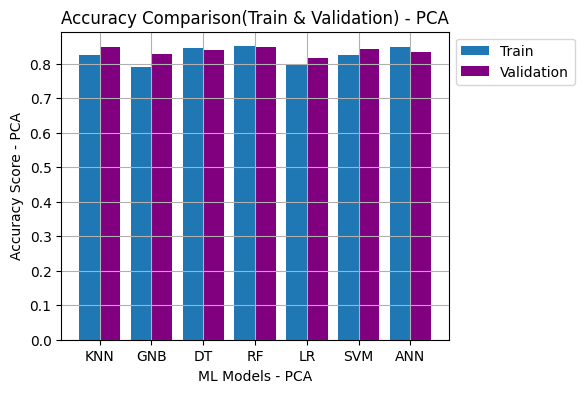

In [898]:
models_pca = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
accuracy_train_pca = [accuracy_train_knn_pca,accuracy_train_nb_pca,accuracy_train_dt_pca,accuracy_train_rf_pca,accuracy_train_lr_pca,accuracy_train_svm_pca,accuracy_train_mlp_pca]
accuracy_test_pca = [accuracy_test_knn_pca,accuracy_test_nb_pca,accuracy_test_dt_pca,accuracy_test_rf_pca,accuracy_test_lr_pca,accuracy_test_svm_pca,accuracy_test_mlp_pca]

plt.figure(figsize=(5,4))
x = np.arange(len(models))
plt.bar(x, accuracy_train, width=0.4, label="Train")
plt.bar(x + 0.4, accuracy_test, width=0.4, label="Validation", color="purple")
plt.xticks(x + 0.2, models)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title('Accuracy Comparison(Train & Validation) - PCA')
plt.xlabel("ML Models - PCA")
plt.ylabel('Accuracy Score - PCA')
plt.grid()
plt.show()

# SVD

In [899]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=3)

X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

### 1. KNN-SVD

In [900]:
knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train_svd, y_train)

y_pred_train_knn_svd = knn.predict(X_train_svd)
y_pred_test_knn_svd = knn.predict(X_test_svd)

accuracy_train_knn_svd, accuracy_test_knn_svd, precision_knn_svd, recall_knn_svd, f1_knn_svd = evaluation_metrics(y_train, y_pred_train_knn_svd, y_test, y_pred_test_knn_svd)

Accuracy Train: 0.7991573033707865
Accuracy Test: 0.7988826815642458
Precision: 0.7323943661971831
Recall: 0.7536231884057971
F1_Score:0.7428571428571429

Confusion_Matrix:
[[91 19]
 [17 52]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       110
           1       0.73      0.75      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### 2. GaussianNB-SVD

In [901]:
nb = GaussianNB()
nb.fit(X_train_svd, y_train)

y_pred_train_nb_svd = nb.predict(X_train_svd)
y_pred_test_nb_svd = nb.predict(X_test_svd)

accuracy_train_nb_svd, accuracy_test_nb_svd, precision_nb_svd, recall_nb_svd, f1_nb_svd = evaluation_metrics(y_train, y_pred_train_nb_svd, y_test, y_pred_test_nb_svd)

Accuracy Train: 0.726123595505618
Accuracy Test: 0.7318435754189944
Precision: 0.7441860465116279
Recall: 0.463768115942029
F1_Score:0.5714285714285714

Confusion_Matrix:
[[99 11]
 [37 32]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.73      0.90      0.80       110
           1       0.74      0.46      0.57        69

    accuracy                           0.73       179
   macro avg       0.74      0.68      0.69       179
weighted avg       0.73      0.73      0.71       179



### 3. Decision Tree-SVD

In [902]:
dt = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=4, min_samples_split=10)
dt.fit(X_train_svd, y_train)

y_pred_train_dt_svd = dt.predict(X_train_svd)
y_pred_test_dt_svd = dt.predict(X_test_svd)

accuracy_train_dt_svd, accuracy_test_dt_svd, precision_dt_svd, recall_dt_svd, f1_dt_svd = evaluation_metrics(y_train, y_pred_train_dt_svd, y_test, y_pred_test_dt_svd)

Accuracy Train: 0.8230337078651685
Accuracy Test: 0.776536312849162
Precision: 0.7164179104477612
Recall: 0.6956521739130435
F1_Score:0.7058823529411765

Confusion_Matrix:
[[91 19]
 [21 48]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.72      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



### 4. Random Forest-SVD

In [903]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features='sqrt')
rf.fit(X_train_svd, y_train)
y_pred_train_rf_svd = rf.predict(X_train_svd)
y_pred_test_rf_svd = rf.predict(X_test_svd)

accuracy_train_rf_svd, accuracy_test_rf_svd, precision_rf_svd, recall_rf_svd, f1_rf_svd = evaluation_metrics(y_train, y_pred_train_rf_svd, y_test, y_pred_test_rf_svd)

Accuracy Train: 0.8398876404494382
Accuracy Test: 0.7821229050279329
Precision: 0.734375
Recall: 0.6811594202898551
F1_Score:0.706766917293233

Confusion_Matrix:
[[93 17]
 [22 47]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.73      0.68      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



### 5.Logestic Regression-SVD

In [904]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_svd, y_train)

y_pred_train_lr_svd = lr.predict(X_train_svd)
y_pred_test_lr_svd = lr.predict(X_test_svd)

accuracy_train_lr_svd, accuracy_test_lr_svd, precision_lr_svd, recall_lr_svd, f1_lr_svd = evaluation_metrics(y_train, y_pred_train_lr_svd, y_test, y_pred_test_lr_svd)

Accuracy Train: 0.6910112359550562
Accuracy Test: 0.7262569832402235
Precision: 0.6851851851851852
Recall: 0.5362318840579711
F1_Score:0.6016260162601627

Confusion_Matrix:
[[93 17]
 [32 37]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.74      0.85      0.79       110
           1       0.69      0.54      0.60        69

    accuracy                           0.73       179
   macro avg       0.71      0.69      0.70       179
weighted avg       0.72      0.73      0.72       179



### 6. SVM-SVD

In [905]:
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_svd, y_train)
y_pred_train_svm_svd = svm.predict(X_train_svd)
y_pred_test_svm_svd = svm.predict(X_test_svd)

accuracy_train_svm_svd, accuracy_test_svm_svd, precision_svm_svd, recall_svm_svd, f1_svm_svd = evaluation_metrics(y_train, y_pred_train_svm_svd, y_test, y_pred_test_svm_svd)

Accuracy Train: 0.7921348314606742
Accuracy Test: 0.8156424581005587
Precision: 0.7647058823529411
Recall: 0.7536231884057971
F1_Score:0.7591240875912408

Confusion_Matrix:
[[94 16]
 [17 52]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



### 7. ANN-SVD

In [906]:
mlp = MLPClassifier(hidden_layer_sizes=50, max_iter=600, activation='relu', solver='adam')
mlp.fit(X_train_svd, y_train)
y_pred_train_mlp_svd = mlp.predict(X_train_svd)
y_pred_test_mlp_svd = mlp.predict(X_test_svd)

accuracy_train_mlp_svd, accuracy_test_mlp_svd, precision_mlp_svd, recall_mlp_svd, f1_mlp_svd = evaluation_metrics(y_train, y_pred_train_mlp_svd, y_test, y_pred_test_mlp_svd)

Accuracy Train: 0.8089887640449438
Accuracy Test: 0.8212290502793296
Precision: 0.7466666666666667
Recall: 0.8115942028985508
F1_Score:0.7777777777777778

Confusion_Matrix:
[[91 19]
 [13 56]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       110
           1       0.75      0.81      0.78        69

    accuracy                           0.82       179
   macro avg       0.81      0.82      0.81       179
weighted avg       0.83      0.82      0.82       179



e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


## Model Performance Comparison Tables - SVD

In [907]:
results_svd = pd.DataFrame({
    'Model-SVD': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'ANN'],
    'Accuracy Train-SVD': [accuracy_train_knn_svd,accuracy_train_nb_svd,accuracy_train_dt_svd,accuracy_train_rf_svd,accuracy_train_lr_svd,accuracy_train_svm_svd,accuracy_train_mlp_svd],
    'Accuracy Validation-SVD': [accuracy_test_knn_svd,accuracy_test_nb_svd,accuracy_test_dt_svd,accuracy_test_rf_svd,accuracy_test_lr_svd,accuracy_test_svm_svd,accuracy_test_mlp_svd],
    'Precision-SVD': [precision_knn_svd,precision_nb_svd,precision_dt_svd,precision_rf_svd,precision_lr_svd,precision_svm_svd,precision_mlp_svd],
    'Recall-SVD': [recall_knn_svd,recall_nb_svd,recall_dt_svd,recall_rf_svd,recall_lr_svd,recall_svm_svd,recall_mlp_svd],
    'F1 Score-SVD': [f1_knn_svd, f1_nb_svd, f1_dt_svd, f1_rf_svd, f1_lr_svd, f1_svm_svd, f1_mlp_svd]
})
results_svd

,Model-SVD,Accuracy Train-SVD,Accuracy Validation-SVD,Precision-SVD,Recall-SVD,F1 Score-SVD
0,KNN,0.799157,0.798883,0.732394,0.753623,0.742857
1,GaussianNB,0.726124,0.731844,0.744186,0.463768,0.571429
2,Decision Tree,0.823034,0.776536,0.716418,0.695652,0.705882
3,Random Forest,0.839888,0.782123,0.734375,0.681159,0.706767
4,Logistic Regression,0.691011,0.726257,0.685185,0.536232,0.601626
5,SVM,0.792135,0.815642,0.764706,0.753623,0.759124
6,ANN,0.808989,0.821229,0.746667,0.811594,0.777778


## Model Performance Comparison - SVD

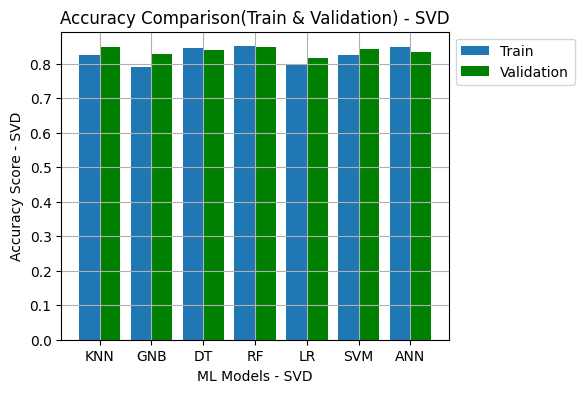

In [908]:
models_svd = ['KNN', 'GNB', 'DT', 'RF', 'LR', 'SVM', 'ANN']
accuracy_train_svd = [accuracy_train_knn_svd,accuracy_train_nb_svd,accuracy_train_dt_svd,accuracy_train_rf_svd,accuracy_train_lr_svd,accuracy_train_svm_svd,accuracy_train_mlp_svd]
accuracy_test_svd = [accuracy_test_knn_svd,accuracy_test_nb_svd,accuracy_test_dt_svd,accuracy_test_rf_svd,accuracy_test_lr_svd,accuracy_test_svm_svd,accuracy_test_mlp_svd]

plt.figure(figsize=(5,4))
x = np.arange(len(models))
plt.bar(x, accuracy_train, width=0.4, label="Train")
plt.bar(x + 0.4, accuracy_test, width=0.4, label="Validation", color="green")
plt.xticks(x + 0.2, models)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title('Accuracy Comparison(Train & Validation) - SVD')
plt.xlabel("ML Models - SVD")
plt.ylabel('Accuracy Score - SVD')
plt.grid()
plt.show()

# Model Comparison : Original - PCA - SVD Tables

In [909]:
Comparison= pd.DataFrame({
    'Model': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'ANN'],
    'Accuracy Train': [accuracy_train_knn,accuracy_train_nb,accuracy_train_dt,accuracy_train_rf,accuracy_train_lr,accuracy_train_svm,accuracy_train_mlp],
    'Accuracy Train-PCA': [accuracy_train_knn_pca,accuracy_train_nb_pca,accuracy_train_dt_pca,accuracy_train_rf_pca,accuracy_train_lr_pca,accuracy_train_svm_pca,accuracy_train_mlp_pca],
    'Accuracy Train-SVD': [accuracy_train_knn_svd,accuracy_train_nb_svd,accuracy_train_dt_svd,accuracy_train_rf_svd,accuracy_train_lr_svd,accuracy_train_svm_svd,accuracy_train_mlp_svd],
    'Accuracy Validation': [accuracy_test_knn,accuracy_test_nb,accuracy_test_dt,accuracy_test_rf,accuracy_test_lr,accuracy_test_svm,accuracy_test_mlp],
    'Accuracy Validation-PCA': [accuracy_test_knn_pca,accuracy_test_nb_pca,accuracy_test_dt_pca,accuracy_test_rf_pca,accuracy_test_lr_pca,accuracy_test_svm_pca,accuracy_test_mlp_pca],
    'Accuracy Validation-SVD': [accuracy_test_knn_svd,accuracy_test_nb_svd,accuracy_test_dt_svd,accuracy_test_rf_svd,accuracy_test_lr_svd,accuracy_test_svm_svd,accuracy_test_mlp_svd],
})
Comparison

,Model,Accuracy Train,Accuracy Train-PCA,Accuracy Train-SVD,Accuracy Validation,Accuracy Validation-PCA,Accuracy Validation-SVD
0,KNN,0.824438,0.811798,0.799157,0.849162,0.843575,0.798883
1,GaussianNB,0.789326,0.779494,0.726124,0.826816,0.815642,0.731844
2,Decision Tree,0.845506,0.856742,0.823034,0.837989,0.821229,0.776536
3,Random Forest,0.849719,0.877809,0.839888,0.849162,0.826816,0.782123
4,Logistic Regression,0.796348,0.772472,0.691011,0.815642,0.804469,0.726257
5,SVM,0.825843,0.800562,0.792135,0.843575,0.826816,0.815642
6,ANN,0.846910,0.834270,0.808989,0.832402,0.837989,0.821229


# Model Comparison : Original - PCA - SVD

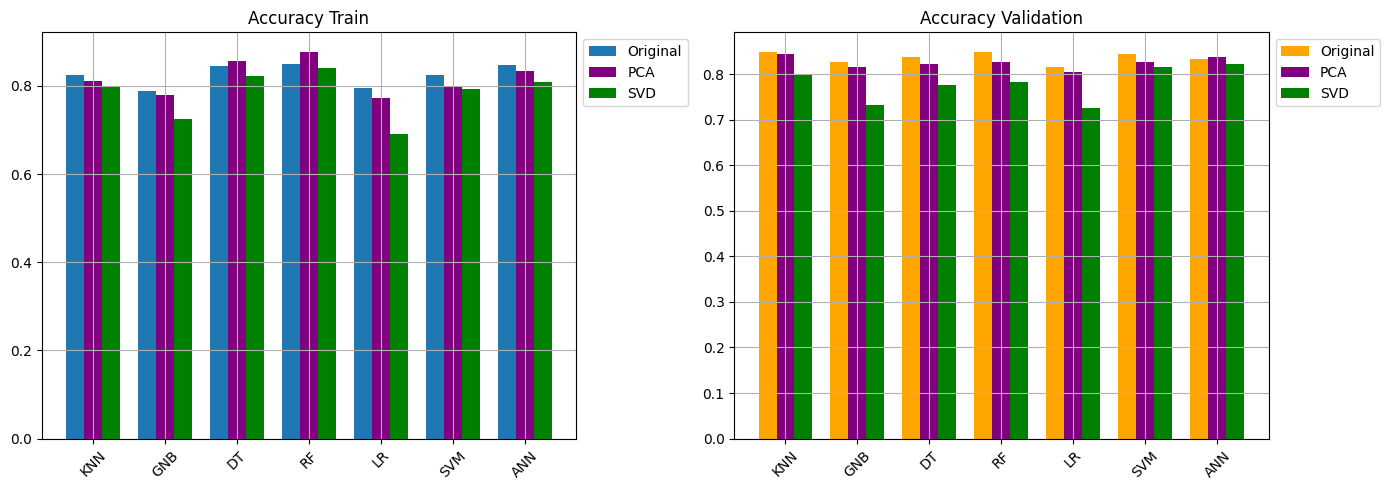

In [910]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [None, 'orange']
metrics = [
   ('Accuracy Train', 'Accuracy Train-PCA', 'Accuracy Train-SVD', 'Accuracy Train'),
   ('Accuracy Validation', 'Accuracy Validation-PCA', 'Accuracy Validation-SVD', 'Accuracy Validation'),
]
for i, (col, col_pca, col_svd, title) in enumerate(metrics):
   x = np.arange(len(models))
   axes[i].bar(x, Comparison[col], width=0.25, label='Original', color=colors[i])
   axes[i].bar(x + 0.25, Comparison[col_pca], width=0.25, label='PCA', color='purple')
   axes[i].bar(x + 0.5, Comparison[col_svd], width=0.25, label='SVD', color='green')
   axes[i].set_xticks(x + 0.25)
   axes[i].set_xticklabels(models, rotation=45)
   axes[i].set_title(title)
   axes[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
   axes[i].grid()
plt.tight_layout()
plt.show()